# Overlap of treatments and encounter fire events (Kelp, et. al., 2025)

In [1]:
import os
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

data_path = "/mnt/sherlock/oak/prescribed_data/"

### 0. Load all data sources

We use two main data sources to capture fire treatments and wildfire events. To capture the first, we use Calfire FRAP and for the second one we use MTBS Events polygons. For both datasets, we subset the data to only contain events from 2010 to 2021. We additionally create an aggregated view to include summary values of the treatments over time (`total_year_rx`).

In [2]:
# Load FRAP prescribed fire data from Calfire and take all fires from 2010 to 
# 2019 that are broadcast burns 
calfire_rx = gpd.read_file(os.path.join(data_path, "geoms/fire24_1.gdb"))
calfire_rx = calfire_rx[
    (~calfire_rx["START_DATE"].isna())
    & (calfire_rx["START_DATE"].dt.year >= 2010)
    & (calfire_rx["START_DATE"].dt.year < 2020)
    & (calfire_rx["TREATMENT_TYPE"] == 1)
]

# Load MTBS and subset to CA fires for the same period and only wildfires
mtbs = gpd.read_file(os.path.join(data_path, "geoms/mtbs_perims_DD_updated/mtbs_perims_DD.shp"))

mtbs = mtbs.assign(
    fire_year = mtbs["Ig_Date"].dt.year,
)

mtbs_ca = mtbs[(mtbs.Event_ID.str.startswith("CA")) &
(mtbs.Ig_Date.dt.year >= 2010) &
(mtbs.Ig_Date.dt.year < 2020) &
(mtbs.Incid_Type == "Wildfire")].to_crs(calfire_rx.crs)

# Add treatment year as the treat year to then follow each treatment against
# observed data
calfire_rx = calfire_rx.assign(
    treat_year=calfire_rx["START_DATE"].dt.year,
)

# Save the number of treatment to calculate the targeting probability
total_year_rx = calfire_rx.groupby("treat_year", as_index=False).agg(
    total_acres=("TREATED_AC", "sum")
)

# Convert acres to square kilometers to compare with overlaps
total_year_rx["total_km"] = total_year_rx["total_acres"] / 247.1 

/home/topcat/miniforge3/envs/prescribed/lib/python3.10/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'fire24_1.gdb': 'rxburn24_1' (default), 'firep24_1'. Specify layer parameter to avoid this warning.
  result = read_func(
/home/topcat/miniforge3/envs/prescribed/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


### 1. Calculate spatial overlap between treatments and events using the total overlap area

We overlap both datasets (projected in meters) and calculate the total area overlap, meaning that we take only the partial or complete overlaps between treatments and fire events. We additionally subset to only include overlaps that happen after the treatment, this is done by using the `treat_year < fire_year` filter. We agregate things  

In [3]:

# Calculate the number of treatments that overlap with each MTBS fire
treatment_meets_fire = calfire_rx.overlay(mtbs_ca, how="intersection")

# Filter out to get only intersections after fire
treatment_meets_fire = treatment_meets_fire[
    treatment_meets_fire.treat_year < treatment_meets_fire.fire_year
]

# Now calculate the area of overlap and scale it to square kilometers
treatment_meets_fire = treatment_meets_fire.assign(
    overlap_km=treatment_meets_fire.geometry.area * 1e-6,
)

# Aggregate and calculate the acres per treated year
treatment_meets_fire_agg = treatment_meets_fire.groupby(["treat_year", "fire_year"], as_index=False).agg({"overlap_km": "sum"})

# Add the size for each treated year to calculate the share treated
calfire_rx_mtbs_agg = treatment_meets_fire_agg.merge(
    total_year_rx,
    on="treat_year",
    how="left",
)

# Calculate the cumulative acres treated per treatment year
calfire_rx_mtbs_agg["cum_treat"] = (
    calfire_rx_mtbs_agg.sort_values(["fire_year", "treat_year"])
    .groupby("treat_year")["overlap_km"]
    .cumsum()
)

# Calculate the cumulative acres as a share of total acres
calfire_rx_mtbs_agg["cum_acres_share"] = (
    calfire_rx_mtbs_agg["cum_treat"] / calfire_rx_mtbs_agg["total_km"]
)

# Create lag variable
calfire_rx_mtbs_agg["lag"] = (
    calfire_rx_mtbs_agg["fire_year"] - calfire_rx_mtbs_agg["treat_year"]
)

### 2. Plot the overlap for each treatment year over time

We want to see how individual treatment years behave across time. To do this, we plot the time series of each treatment year across future time (lags). Some years could have had treatments, but no event in the future overlapped with them, in this case this treatment year will be ignored from the plot. 

/tmp/ipykernel_422799/4120244370.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(


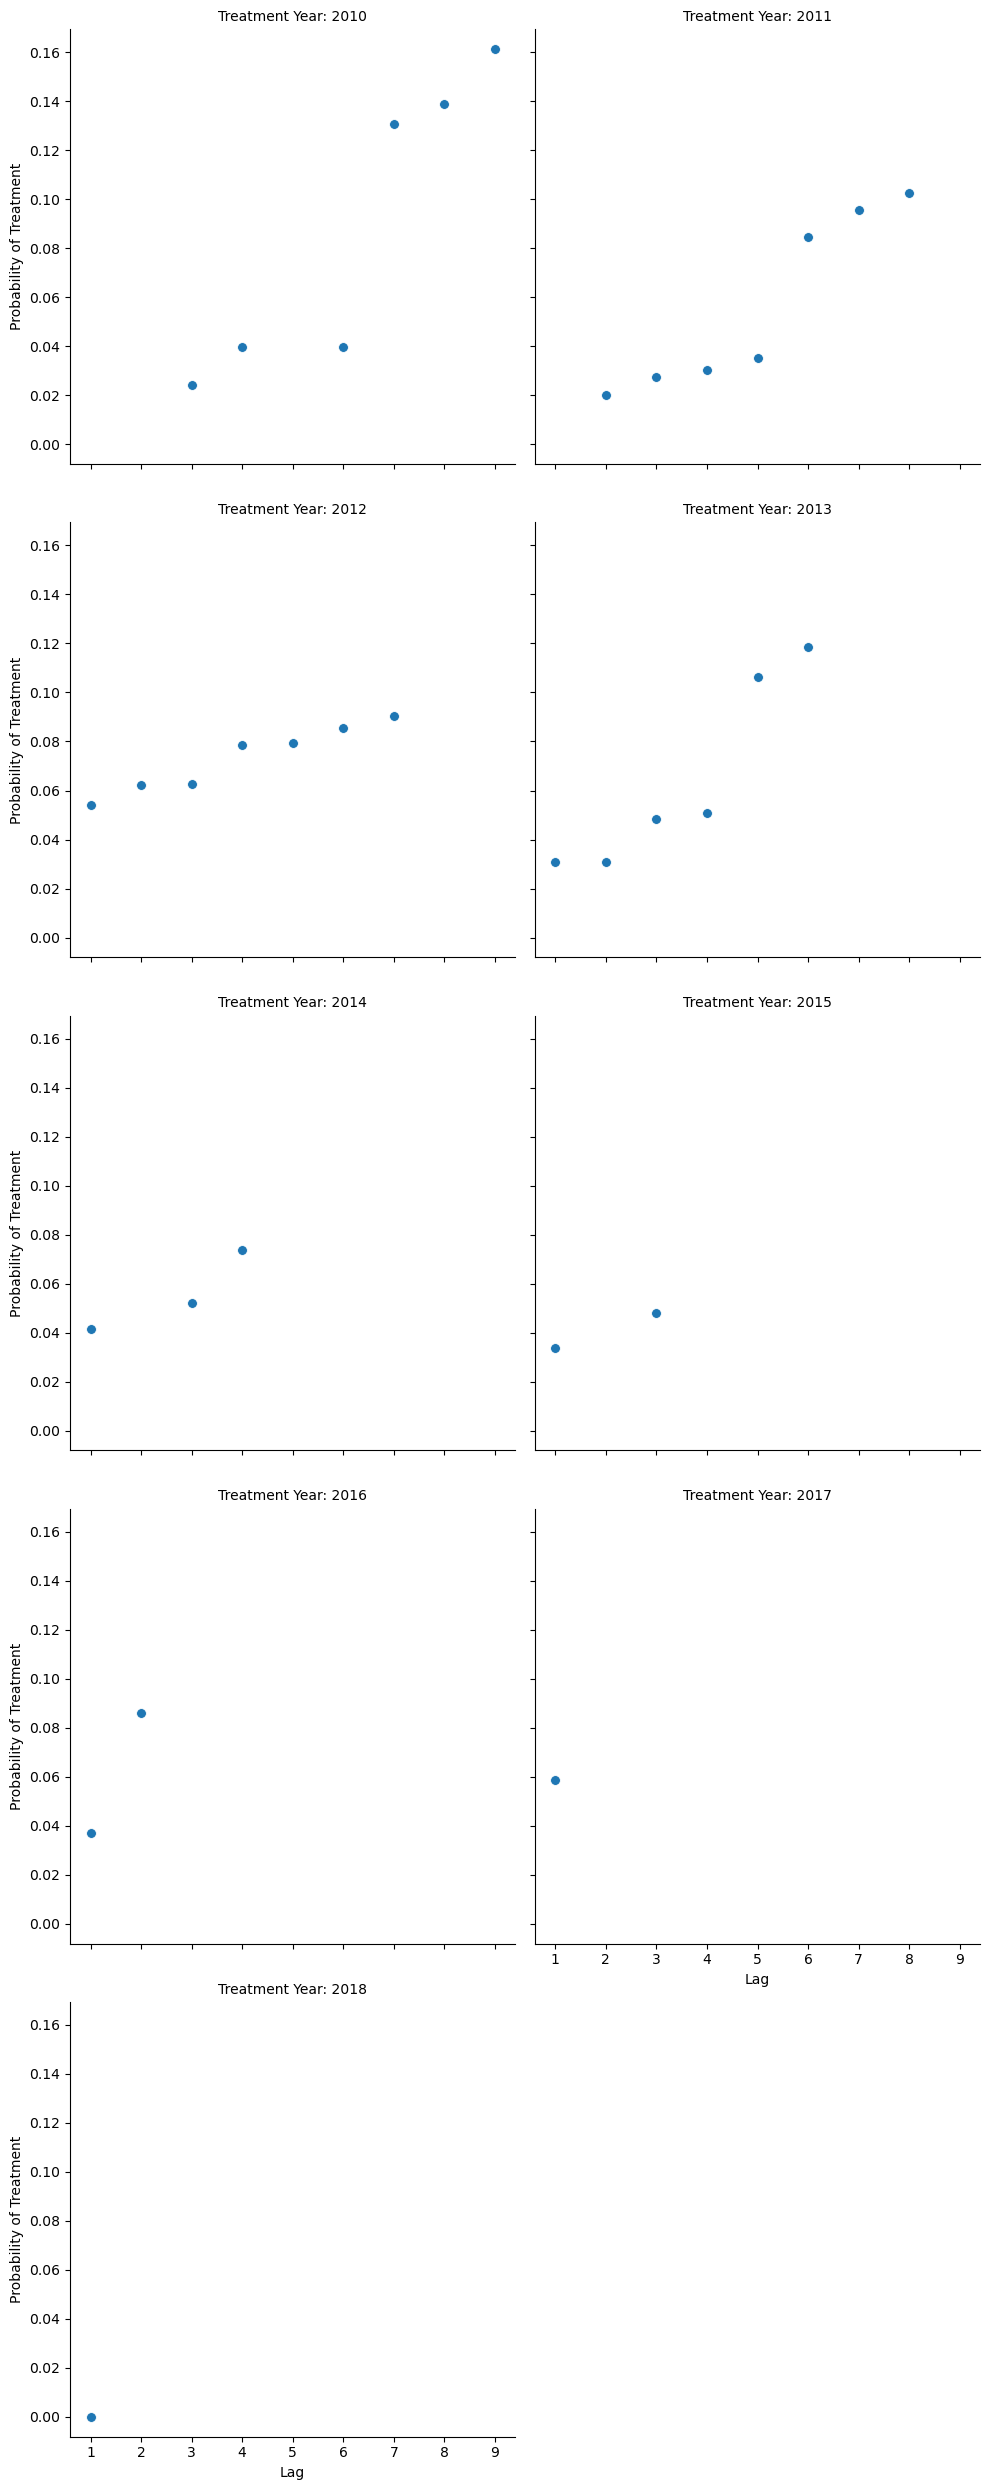

In [4]:
g = sns.relplot(
    data=calfire_rx_mtbs_agg,
    x="lag",
    y="cum_acres_share",
    s=50,
    #linewidth=4,
    col="treat_year",
    palette="Reds",
    kind="scatter",
    col_wrap=2,
    height=5,
    legend=False,
)


g.set_titles("Treatment Year: {col_name}")
g.set_axis_labels("Lag", "Probability of Treatment")
plt.tight_layout()


We can aggregate this and get the mean of these overlaps: 

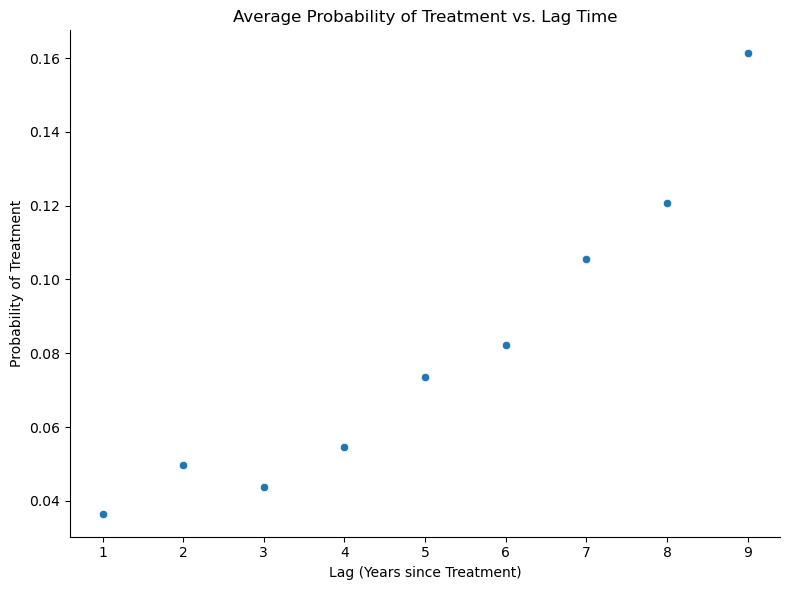

In [5]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(
    data=calfire_rx_mtbs_agg.groupby("lag", as_index=False).mean(),
    x="lag",
    y="cum_acres_share",
)

ax.set_xlabel("Lag (Years since Treatment)")
ax.set_ylabel("Probability of Treatment")
ax.set_title("Average Probability of Treatment vs. Lag Time")

sns.despine()
fig.tight_layout()

### 3. Alternative overlaps 

Another possibility for overlap is to consider other events that are not MTBS or simply a gridded data of the dNBR. This would neccessarily increase the overlap as we're considering all grids potentially affected by a treatment. To do this, we will use dNBR data collected by us using the Landsat 2 Collection. These data come processed from us in Feather format with a `grid_id` that identifies a 1 sq-km grid that we use to align all of our datasets, and an `Event_ID` that overlays with MTBS `Event_ID`. Notice that as we want to keep all the burned data, we keep all dNBR rows, even if they have values smaller than zero. 

In [11]:
# Load DNBR data and save to parquet to make it nicer for DuckDB
dnbr = pd.read_feather(
    os.path.join(data_path, "processed/dnbr_gee/dnbr_long.feather")
).drop(columns=["spatial_ref"], errors="ignore")

# Bottom code the negative dnbr to be zero if negative
# dnbr["dnbr"] = np.where(dnbr.dnbr < 0, 0, dnbr.dnbr)

# Merge it to get years
mtbs["year"] = mtbs.Ig_Date.dt.year

dnbr = dnbr.merge(
    mtbs[["Event_ID", "year"]],
    right_on="Event_ID",
    left_on="event_id",
    how="left",
)
dnbr.drop(columns=["Event_ID"], inplace=True)

# Transform dnbr to geopandas to find the treatments that overlap with fires
dnbr_gdf = gpd.GeoDataFrame(
    dnbr,
    geometry=gpd.points_from_xy(dnbr.lon, dnbr.lat),
    crs="EPSG:3310",
)
dnbr_gdf = dnbr_gdf[(dnbr_gdf.year >= 2010 ) & (dnbr_gdf.year <= 2019)]
dnbr_gdf = dnbr_gdf.to_crs(calfire_rx.crs)


In [16]:
calfire_rx.crs

<Projected CRS: EPSG:3310>
Name: NAD83 / California Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - California.
- bounds: (-124.45, 32.53, -114.12, 42.01)
Coordinate Operation:
- name: California Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### 3.1. Calculate overlaps using a simple spatial join

The `dnbr_gdf` data contains fire severity data. We use our previously filtered `calfire_rx` dataset to calculate the join. Notice that in this join we are comparing polygons (sometimes multi-polygons) and a grid/point dataset. Thus, we will select all grids that touch/intersect or are within a dataset. 


In [13]:
# Get the number of treatments inside a particular fire event in MTBS
calfire_rx_mtbs = gpd.sjoin(
    dnbr_gdf,
    calfire_rx,
    how="inner",
    predicate="within",
)

# Remove all the matches before the treat year
calfire_rx_mtbs = calfire_rx_mtbs[
    calfire_rx_mtbs.year > calfire_rx_mtbs.treat_year
]

# Aggregate the number of unique grids treated per treatment year and year
# to get the count of times that the fires overlap
calfire_rx_mtbs_agg = calfire_rx_mtbs.groupby(
    ["treat_year", "year"], as_index=False
).agg(size=("grid_id", "nunique"))

# Add the size for each treated year to calculate the share treated
calfire_rx_mtbs_agg = calfire_rx_mtbs_agg.merge(
    total_year_rx,
    on="treat_year",
    how="left",
)

# Calculate the cumulative acres treated per treatment year
calfire_rx_mtbs_agg["cum_treat"] = (
    calfire_rx_mtbs_agg.sort_values(["year", "treat_year"])
    .groupby("treat_year")["size"]
    .cumsum()
)

# Calculate the cumulative acres as a share of total acres
calfire_rx_mtbs_agg["cum_acres_share"] = (
    calfire_rx_mtbs_agg["cum_treat"] / calfire_rx_mtbs_agg["total_km"]
)

# Calculate lag
calfire_rx_mtbs_agg["lag"] = (
    calfire_rx_mtbs_agg["year"] - calfire_rx_mtbs_agg["treat_year"]
)

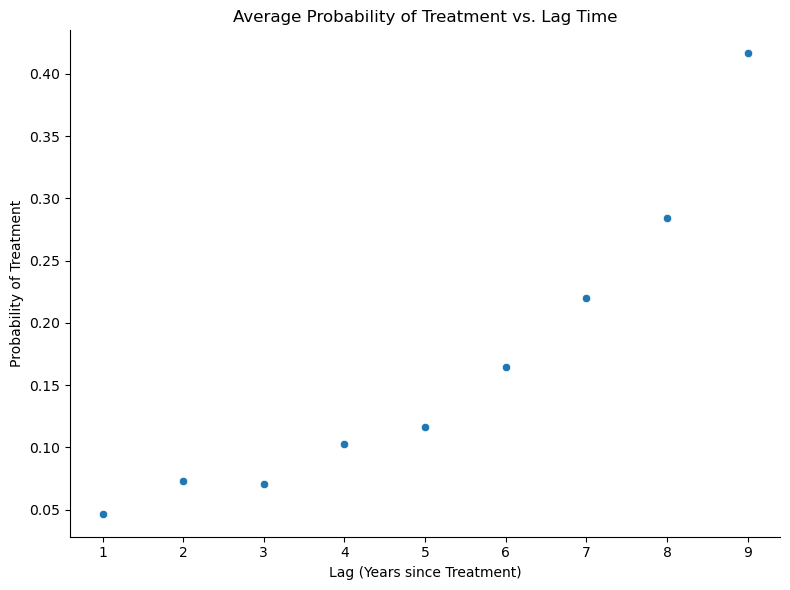

In [14]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(
    data=calfire_rx_mtbs_agg.groupby("lag", as_index=False).mean(),
    x="lag",
    y="cum_acres_share",
)

ax.set_xlabel("Lag (Years since Treatment)")
ax.set_ylabel("Probability of Treatment")
ax.set_title("Average Probability of Treatment vs. Lag Time")

sns.despine()
fig.tight_layout()